<a href="https://colab.research.google.com/github/Rifath-Mahmud/CVPR/blob/main/Introduction_to_Deep_Learning_MNIST_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [2]:
data_folder = '~/data/MNIST'

# Load train data
mnist_train = datasets.MNIST(root=data_folder, train=True, download=True)
tr_images = mnist_train.data
tr_targets = mnist_train.targets

# Load test data
mnist_test = datasets.MNIST(root=data_folder, train=False, download=True)
te_images = mnist_test.data
te_targets = mnist_test.targets

print("Train images:", tr_images.shape, "\tTrain labels:", tr_targets.shape)
print("Test images: ", te_images.shape,  "\tTest labels: ",  te_targets.shape)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 444kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.8MB/s]

Train images: torch.Size([60000, 28, 28]) 	Train labels: torch.Size([60000])
Test images:  torch.Size([10000, 28, 28]) 	Test labels:  torch.Size([10000])


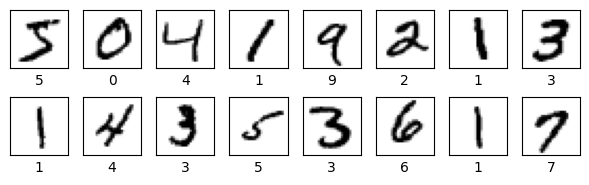

In [3]:
ROWS, COLS = 2 , 8
fig, axes = plt.subplots(ROWS, COLS, figsize=(6, 2))
for i, ax in enumerate(axes.flat):
    ax.imshow(tr_images[i], cmap="gray_r")
    ax.set_xlabel(tr_targets[i].item())
    ax.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

In [4]:
class MNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255.0
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        return self.x[ix], self.y[ix]

    def __len__(self):
        return len(self.x)


In [5]:
train = MNISTDataset(tr_images, tr_targets)
trn_dl = DataLoader(train, batch_size=32, shuffle=True)

test = MNISTDataset(te_images, te_targets)
te_dl = DataLoader(test, batch_size=32, shuffle=False)

In [6]:
from torch.optim import SGD

def get_model():
    model = nn.Sequential(
                nn.Linear(28 * 28, 256),
                nn.ReLU(),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, 10)
            ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer


In [7]:
def train_batch(x, y, model, loss_fn, optimizer):
    model.train()
    optimizer.zero_grad()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    return batch_loss.item()

@torch.no_grad()
def batch_accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()


def train_one_epoch(data_loader, model, loss_fn, optimizer):
    epoch_losses, epoch_accuracies = [], []
    for batch in data_loader:
        x, y = batch
        x, y = x.to(device), y.to(device)   # move to device here
        batch_loss = train_batch(x, y, model, loss_fn, optimizer)
        epoch_losses.append(batch_loss)
        epoch_accuracies.extend(batch_accuracy(x, y, model))
    return np.array(epoch_losses).mean(), np.array(epoch_accuracies).mean()


@torch.no_grad()
def validation(data_loader, model, loss_fn):
    val_losses, val_accuracies = [], []
    model.eval()
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)   # move to device here
        prediction = model(x)
        val_losses.append(loss_fn(prediction, y).item())
        val_accuracies.extend(batch_accuracy(x, y, model))
    return np.array(val_losses).mean(), np.array(val_accuracies).mean()


In [8]:
## Training Loop ###
model, loss_fn, optimizer = get_model()
losses, accuracies = [], []
val_losses, val_accuracies = [], []
training_epoch = 10

for epoch in range(training_epoch):
  epoch_loss, epoch_accuracy = train_one_epoch(trn_dl,model,loss_fn,optimizer)
  losses.append(epoch_loss)
  accuracies.append(epoch_accuracy)

  v_loss, v_acc =  validation(te_dl,model,loss_fn)
  val_losses.append(v_loss)
  val_accuracies.append(v_acc)

  print(f"Epoch [{epoch + 1}/{training_epoch}]"
        f" | Train Loss: {epoch_loss:.4f} | Train Accuracy: {epoch_accuracy*100:.2f}%"
        f" | Val Loss: {v_loss:.4f} | Val Accuracy: {v_acc*100:.2f}%")

Epoch [1/10] | Train Loss: 2.2783 | Train Accuracy: 23.34% | Val Loss: 2.2364 | Val Accuracy: 44.23%
Epoch [2/10] | Train Loss: 2.1590 | Train Accuracy: 57.10% | Val Loss: 2.0365 | Val Accuracy: 64.81%
Epoch [3/10] | Train Loss: 1.8237 | Train Accuracy: 66.12% | Val Loss: 1.5430 | Val Accuracy: 70.22%
Epoch [4/10] | Train Loss: 1.2896 | Train Accuracy: 74.00% | Val Loss: 1.0318 | Val Accuracy: 78.63%
Epoch [5/10] | Train Loss: 0.8936 | Train Accuracy: 80.14% | Val Loss: 0.7484 | Val Accuracy: 82.56%
Epoch [6/10] | Train Loss: 0.6906 | Train Accuracy: 83.05% | Val Loss: 0.6078 | Val Accuracy: 84.66%
Epoch [7/10] | Train Loss: 0.5839 | Train Accuracy: 85.02% | Val Loss: 0.5282 | Val Accuracy: 86.31%
Epoch [8/10] | Train Loss: 0.5196 | Train Accuracy: 86.27% | Val Loss: 0.4771 | Val Accuracy: 87.26%
Epoch [9/10] | Train Loss: 0.4757 | Train Accuracy: 87.20% | Val Loss: 0.4400 | Val Accuracy: 88.13%
Epoch [10/10] | Train Loss: 0.4439 | Train Accuracy: 87.94% | Val Loss: 0.4137 | Val Accura

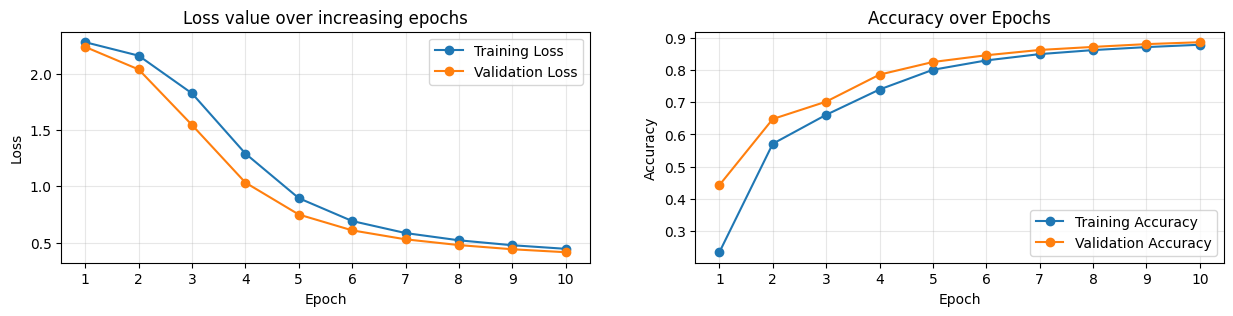

In [9]:
epochs = np.arange(training_epoch) + 1
plt.figure(figsize=(15, 3))
plt.subplot(121)
plt.title("Loss value over increasing epochs")
plt.plot(epochs, losses, marker='o', label="Training Loss")
plt.plot(epochs, val_losses, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(122)
plt.title("Accuracy over Epochs")
plt.plot(epochs, accuracies, marker='o', label="Training Accuracy")
plt.plot(epochs, val_accuracies, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()